# Windowing and Resampling

In this notebook, we are going to investigate how to use `rasterio` to load a windowed and resized area of interest (AOI) out of a bigger raster. These functionalities allow us to perform useful pre-processing operations like:

- Cutting the AOI out of the provided tile.
- Resample the raster to up/downsample a band to match the desired analysis resolution algorithmically.

In [1]:
%load_ext autoreload
%autoreload 2

In [35]:
import matplotlib.pyplot as plt
import rasterio
from dotenv import load_dotenv
from rasterio import transform, warp
from rasterio.enums import Resampling
from rasterio.windows import from_bounds

from lulc.config.viz import load_viz_config
from lulc.data.sentinel2 import ResamplingStrategy, get_scene
from lulc.io import VIZ_CONFIG
from lulc.viz.images import robust_plot, set_matplotlib_global_config

load_dotenv()
viz_cfg = load_viz_config(VIZ_CONFIG)
set_matplotlib_global_config(viz_cfg)

As a reference tile, we are going to use a region of Andalusia (Spain), the same as that analyzed across the entire project. The URL points to the green band at 10 m resolution.

In [3]:
href_andalusia = "s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/12/27/S2B_MSIL2A_20221227T111359_N0510_R137_T30STG_20240807T153102.SAFE/GRANULE/L2A_T30STG_A030336_20221227T111439/IMG_DATA/R10m/T30STG_20221227T111359_B02_10m.jp2"

## Windowing

When we want to analyse a specific area, with well-defined boundaries, the odds that this area matches the boundaries of a recorded tile from a satellite are very fews. We can for example, need only a small part of the entire recorded tile, or we could need to combine multiple of them and then keep only some pixels of the resulting raster.

Windowing helps us in this situations

In [4]:
with rasterio.open(href_andalusia) as src:
    data_tile = src.read(1)
    bounds_tile = src.bounds
    crs = src.crs
    _transform = src.transform

In [5]:
print(crs)
print(bounds_tile)

EPSG:32630
BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)


This scene has been obtained by using the following bounding box in the STAC filter of the CDSE:

In [6]:
bounds_aoi = [
    -6.362565950090263,
    37.00620706676072,
    -5.798434049909736,
    37.45839293323928,
]

To understand if this bounding box is the same as the recovered tile, we first have to convert them to the same reference system.

Our bounding box is specified in terms of **latitude and longitude** coordinates, i.e. in the **geographic coordinate systems** defined by the [EPSG:4326](https://epsg.io/4326). From the previous lines, we can see that the raster is instead defined in the [EPSG:32630](http://epsg.io/32630) system. Despite the two systems having the same datum, they are intrinsically different. The former does not use any reprojection, a system used by the GPS but not suited to compute distances. The reason is that the degrees to meters conversion is not constant and varies from the equator to the poles. To solve this issue, *we need to reproject the 3D model of the Earth into a Cartesian plane*. In particular, we can have different reprojections, each valid only in a narrow region around the reprojection point because transforming an ellipsoid into a planar object inevitably introduces distortions. The **EPSG:32630** is exactly a reprojection that is accurate in the neighborhood of our AOI.

So, we first need to convert the obtained bounds of the tile into our **EPSG:4326**. To do so, we can use the `rasterio.warp` package, which provides utilities for raster warping and reprojection:

In [7]:
bounds_tile_deg = warp.transform_bounds(crs, "EPSG:4326", *bounds_tile)
bounds_tile_deg

(-6.411972478670402, 36.910119161131085, -5.13602504583506, 37.927680432889204)

To interpret this result, we need to recall that a bounding box is specified by defining the (lat, lon) pair for the point on the bottom-left and those for the point on the top-right of our parallelepiped. Since the coordinates of our AOI are higher than the ones of the tile for the west-south, and lower for the east-north, our AOI is fully contained in the tile.

Let's first visualize the original tile:

Text(0, 0.5, 'latitude [m]')

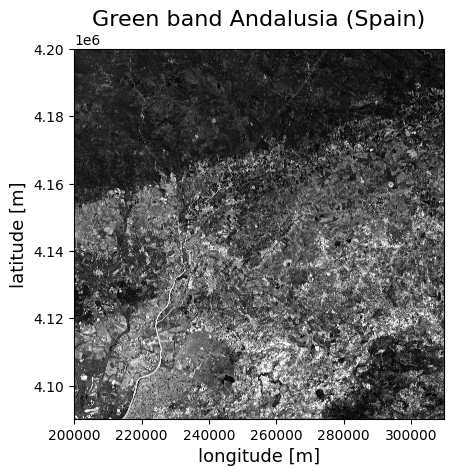

In [39]:
bounds_tile_list = [
    bounds_tile.left,
    bounds_tile.bottom,
    bounds_tile.right,
    bounds_tile.top,
]
robust_plot(data_tile, bounds_tile_list)
plt.title("Green band Andalusia (Spain)")
plt.xlabel("longitude [m]")
plt.ylabel("latitude [m]")

Now we want to only download the cropped AOI from the STAC database. When our computational resources are limited this helps us in reducing the required burden.

In [10]:
left, bottom, right, top = warp.transform_bounds("EPSG:4326", crs, *bounds_aoi)
window = from_bounds(
    left=left,
    bottom=bottom,
    right=right,
    top=top,
    transform=_transform,
)

scene = get_scene(href_andalusia, window, ResamplingStrategy())

We can now reconvert the AOI from the geographic reference system in degrees into the more familiar Cartesian system:

Text(0, 0.5, 'latitude [m]')

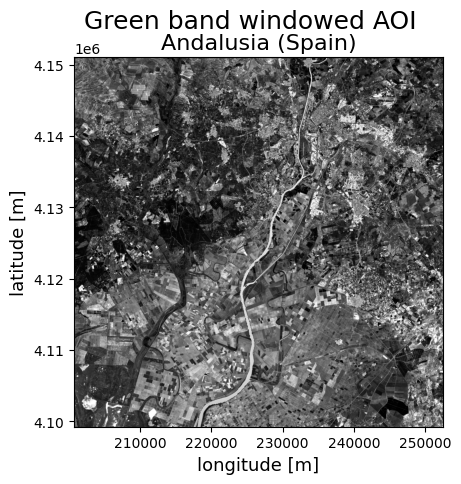

In [40]:
bounds_aoi_m = warp.transform_bounds("EPSG:4326", "EPSG:32630", *bounds_aoi)
robust_plot(scene, bounds_aoi_m)
plt.suptitle("Green band windowed AOI")
plt.title("Andalusia (Spain)")
plt.xlabel("longitude [m]")
plt.ylabel("latitude [m]")

We can see that even though we specified the same length for our AOI in both vertical and horizontal directions, the conversion inevitabely introduced some error and the shape of our raster is not squared:

In [12]:
scene.shape

(5181, 5169)

While the Sentinel-2 tile was perfectly squared:

In [13]:
data_tile.shape

(10980, 10980)

## Resampling

Let's investigate how to perform resampling of the dataset to algorithmically increase or decrease the resolution. Given that we are working with radiance, a continuous variable, we can use a bilinear interpolation method to increase the number of points in the same bounding box:

In [43]:
resampling = ResamplingStrategy(2, Resampling.bilinear)
scene_oversampled = get_scene(href_andalusia, window, resampling)

As expected, the number of points now doubled:

In [44]:
scene_oversampled.shape

(10362, 10338)

Text(0, 0.5, 'latitude [m]')

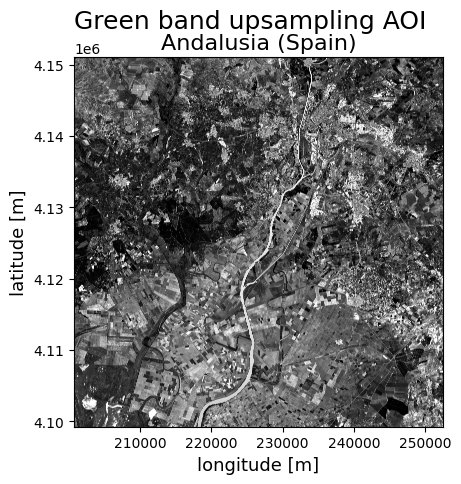

In [45]:
robust_plot(new, bounds_aoi_m)
plt.suptitle("Green band upsampling AOI")
plt.title("Andalusia (Spain)")
plt.xlabel("longitude [m]")
plt.ylabel("latitude [m]")

Not that having performed the resampling, we should also reflect this change in pixel to meter size in the affine transformation of the GeoTIFF image.

We can now perform an upscaling reducing the resolution of the raster:

In [48]:
resampling = ResamplingStrategy(1 / 32, Resampling.bilinear)
scene_downsampled = get_scene(href_andalusia, window, resampling)

In [49]:
scene_downsampled.shape

(161, 161)

Text(0, 0.5, 'latitude [m]')

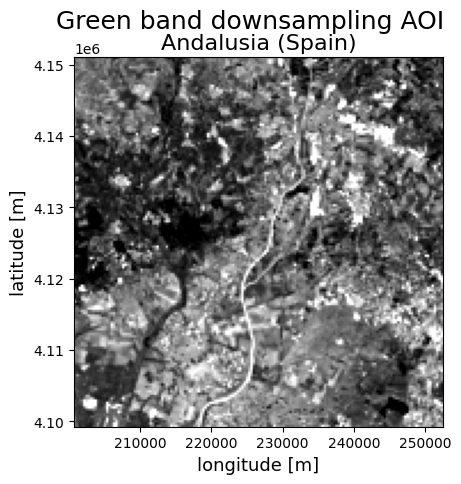

In [51]:
robust_plot(scene_downsampled, bounds_aoi_m)
plt.suptitle("Green band downsampling AOI")
plt.title("Andalusia (Spain)")
plt.xlabel("longitude [m]")
plt.ylabel("latitude [m]")

## Affine Transformation Analysis

In [52]:
from rasterio.windows import transform as window_transform

In [53]:
with rasterio.open(href_andalusia) as src:
    crs = src.crs
    transform = src.transform

window_bbox = bounds_aoi

# Transform from degree to meters.
left, bottom, right, top = warp.transform_bounds("EPSG:4326", crs, *window_bbox)

window = from_bounds(
    left=left,
    bottom=bottom,
    right=right,
    top=top,
    transform=transform,
)

In [54]:
transform

Affine(10.0, 0.0, 199980.0,
       0.0, -10.0, 4200000.0)

In [55]:
print(bounds_tile)

BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)


In [56]:
cropped_transform = window_transform(window, transform)

In [57]:
cropped_transform

Affine(10.0, 0.0, np.float64(200788.7171578621),
       0.0, -10.0, np.float64(4151036.8791220747))

In [58]:
bounds_aoi_m

(200788.7171578621, 4099222.676910201, 252483.18081873987, 4151036.8791220747)

## Memory Effort Analysis

Given the high number of images we are going to use and the limited resources I have available, it can be interesting to estimate the overall memory requirement.

What we will have, for each scene, is:

- 10 bands at 10m resolution with reflectance values.
- 1 band at 10m resolution with the Scene CLassification (SCL).

So, we will have 10 bands requiring 2 bytes (`uint16`) per pixel and 1 band requiring 1 byte per pixel (SCL). To limit the disk requirement, we limited each season to have a maximum of 10 scenes. We can approximate and assume all the pixels require 2 bytes and we obtain:

In [60]:
disk_requirement = scene.shape[0] * scene.shape[1] * 2 * 11 / 1024 / 1024 / 1024
print(f"Disk requirement for single image: {disk_requirement} GB")
print(f"Disk requirement total: {disk_requirement * 40} GB")

Disk requirement for single image: 0.5487100761383772 GB
Disk requirement total: 21.948403045535088 GB
